In [9]:
import sys
sys.path.append('../src')

import pandas as pd
from preprocessing import run_preprocessing_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [10]:
result = run_preprocessing_pipeline('../data/raw/PS_20174392719_1491204439457_log.csv')

Shape initiale : (6362620, 11)
Taux de fraude : 0.1291%


In [14]:
X_train = result['X_train']
X_test = result['X_test']
y_train = result['y_train']
y_test = result['y_test']

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(5090096, 11) (1272524, 11)
0.0012907418642005967 0.0012911347840983745


In [4]:
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
model_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [5]:
y_pred = model_lr.predict(X_test)
y_proba = model_lr.predict_proba(X_test)[:, 1]

print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1-score  :", f1_score(y_test, y_pred))
print("ROC-AUC   :", roc_auc_score(y_test, y_proba))

Precision : 0.024152500083169767
Recall    : 0.8837492391965917
F1-score  : 0.04701996405498616
ROC-AUC   : 0.9751694879465155


## Modele 2 - Random Forest

Contrairement a la Logistic Regression, Random Forest peut capturer des relations
non lineaires et des combinaisons de conditions (seuils), plus adaptees a la nature
des patterns de fraude identifies dans l'EDA (compte vide, montant eleve, heure de
la transaction). On utilise class_weight='balanced' pour compenser le desequilibre
extreme de classes (0.13% de fraude).

In [21]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
model_rf.fit(X_train_reduit, y_train)

NameError: name 'RandomForestClassifier' is not defined

In [ ]:
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall    :", recall_score(y_test, y_pred_rf))
print("F1-score  :", f1_score(y_test, y_pred_rf))
print("ROC-AUC   :", roc_auc_score(y_test, y_proba_rf))

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

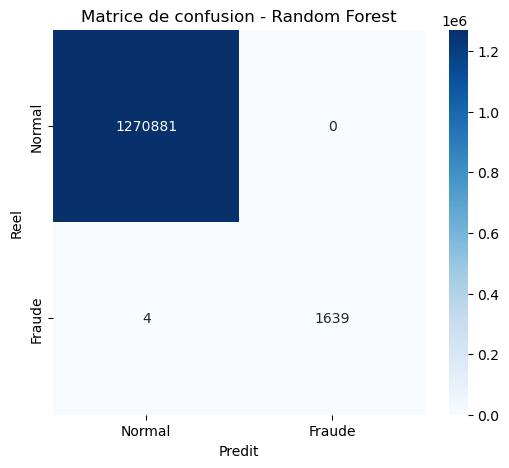

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Predit')
plt.ylabel('Reel')
plt.title('Matrice de confusion - Random Forest')
plt.show()

## Resultat Random Forest

Precision 1.0, Recall 0.998, F1 0.999. Un score presque parfait, nettement
superieur a la Logistic Regression (F1 0.047). Ce resultat quasi parfait est
suspect et merite verification, voir le test de diagnostic ci-dessous.

## Test de diagnostic - dependance aux variables de solde

Le score quasi parfait de Random Forest interroge. On teste ici si le modele
s'appuie fortement sur les variables liees au solde (origBalanceEmptied,
errorBalanceOrig, errorBalanceDest, et les soldes bruts), en les retirant
temporairement, pour verifier s'il reste performant avec des signaux plus
indirects (type, amount, hour_of_day).

In [15]:
colonnes_a_retirer = ['origBalanceEmptied', 'errorBalanceOrig', 'errorBalanceDest',
                       'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

X_train_reduit = X_train.drop(columns=colonnes_a_retirer)
X_test_reduit = X_test.drop(columns=colonnes_a_retirer)

X_train_reduit.columns.tolist()

['step', 'type_encoded', 'amount', 'hour_of_day']

In [16]:
model_rf_reduit = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
model_rf_reduit.fit(X_train_reduit, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred_reduit = model_rf_reduit.predict(X_test_reduit)
y_proba_reduit = model_rf_reduit.predict_proba(X_test_reduit)[:, 1]

print("Precision :", precision_score(y_test, y_pred_reduit))
print("Recall    :", recall_score(y_test, y_pred_reduit))
print("F1-score  :", f1_score(y_test, y_pred_reduit))
print("ROC-AUC   :", roc_auc_score(y_test, y_proba_reduit))

Precision : 0.03810784213919712
Recall    : 0.6835057821059038
F1-score  : 0.07219079454872718
ROC-AUC   : 0.9538588330137459


In [32]:
cm_reduit = confusion_matrix(y_test, y_pred_reduit)
print(cm_reduit)

[[1242535   28346]
 [    520    1123]]


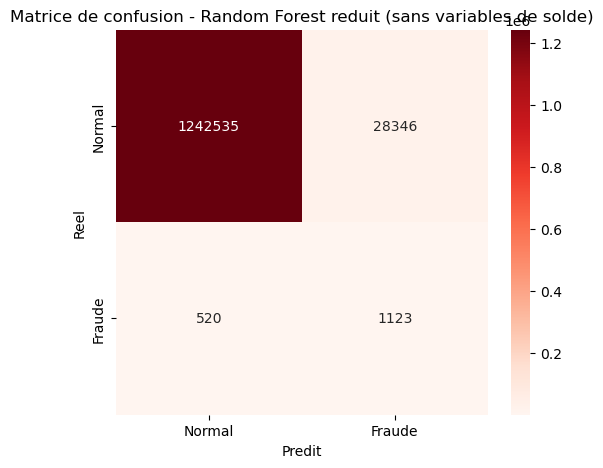

In [33]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_reduit, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Predit')
plt.ylabel('Reel')
plt.title('Matrice de confusion - Random Forest reduit (sans variables de solde)')
plt.show()

## Resultat du test de diagnostic

La performance s'effondre nettement sans ces variables (F1 de 0.999 a 0.072,
28346 faux positifs contre 0). Cela confirme que le modele s'appuie fortement
sur origBalanceEmptied et les soldes. Ces variables restent conservees dans le
modele final car elles representent un signal metier legitime et disponible au
moment de la prediction (le solde apres transaction est connu par le systeme),
pas une fuite d'information artificielle comme une donnee du futur.

## Visualisation d'un arbre - confirmation visuelle

Pour confirmer visuellement ce que le test de diagnostic a revele en chiffres,
on affiche un arbre individuel de Random Forest, afin de voir concretement
quelle variable il utilise en priorite pour ses decisions.

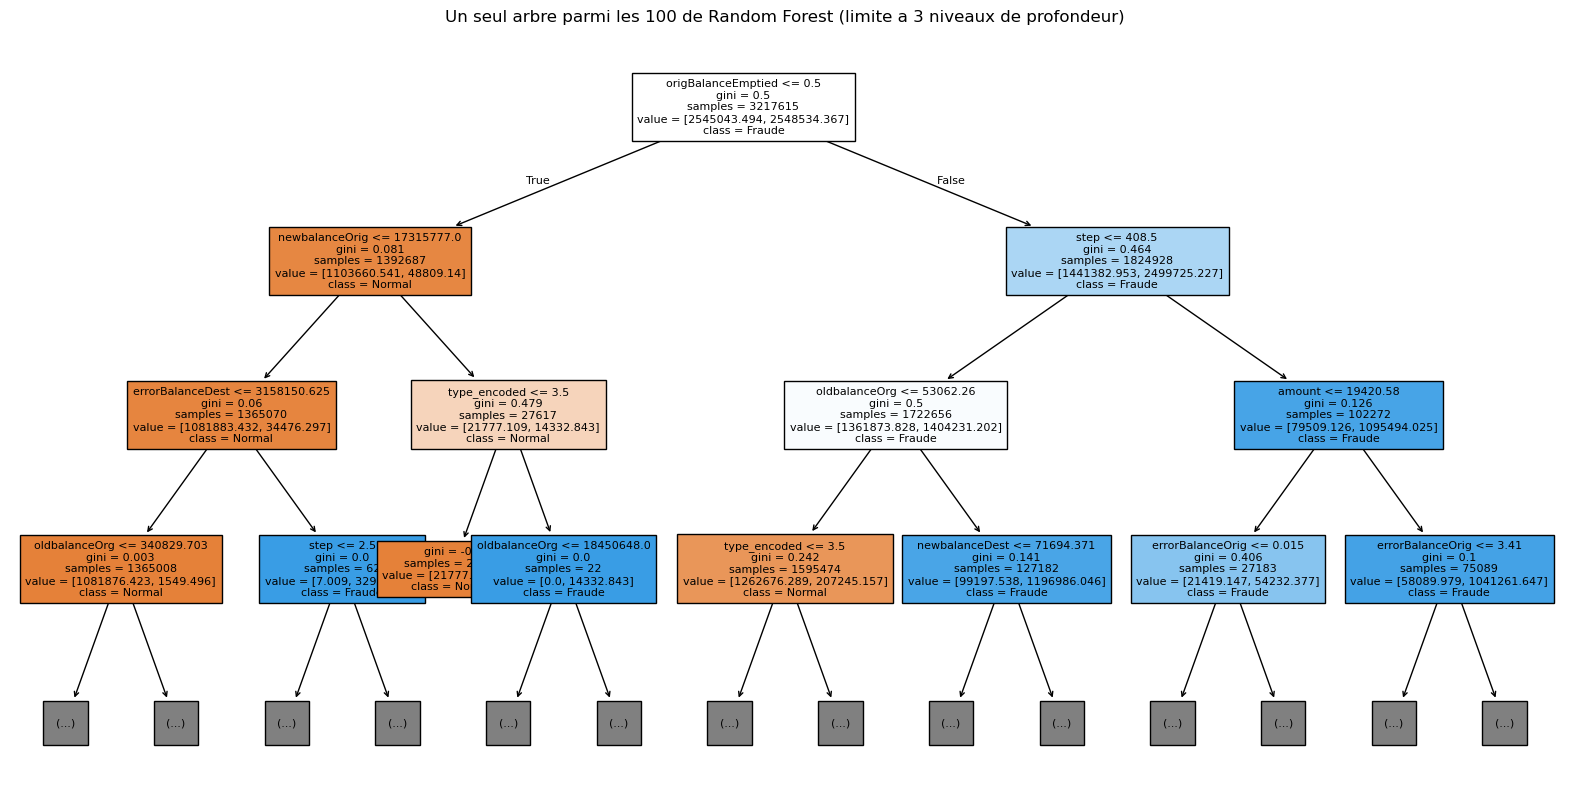

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(model_rf.estimators_[0], max_depth=3, feature_names=X_train.columns,
          class_names=['Normal', 'Fraude'], filled=True, fontsize=8)
plt.title('Un seul arbre parmi les 100 de Random Forest (limite a 3 niveaux de profondeur)')
plt.show()

## Modele 3 - XGBoost

XGBoost construit ses arbres de facon sequentielle, chaque nouvel arbre corrigeant
les erreurs des precedents, contrairement a Random Forest qui construit ses arbres
independamment. Souvent plus performant que Random Forest sur ce type de probleme.
On utilise scale_pos_weight (calcule dans le pipeline de preprocessing) plutot que
class_weight, qui est le mecanisme equivalent propre a XGBoost pour gerer le
desequilibre de classes.

In [36]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 3.0 MB/s eta 0:00:16
   - -------------------------------------- 1.8/48.9 MB 3.2 MB/s eta 0:00:15
   - -------------------------------------- 2.1/48.9 MB 3.0 MB/s eta 0:00:16
   - -------------------------------------- 2.4/48.9 MB 2.8 MB/s eta 0:00:17
   -- ------------------------------------- 2.6/48.9 MB 2.4 MB/s eta 0:00:20
   -- ------------------------------------- 2.9/48.9 MB 2.0 MB/s eta 0:00:23
   -- ------------------------------------- 3.4/48.9 MB 2.1 MB/s eta 0:00:22
   --- ------------------------------------ 3.9/48.9 MB 2.1 MB/s eta 0:00:22
   --- ------------------------------------ 4.5/48.9 MB 2.1 MB/s eta 0:00:21
   ---- ----------------------------------- 5.0/48.9 MB 2.2 MB/s eta 0:00:21
   ---- ----------------------------------- 5.8/48.9 MB 2.3 MB/s eta 0:00:20
   ---- -----

In [16]:
from xgboost import XGBClassifier

scale_pos_weight = result['scale_pos_weight']

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
model_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [18]:
y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("Precision :", precision_score(y_test, y_pred_xgb))
print("Recall    :", recall_score(y_test, y_pred_xgb))
print("F1-score  :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC   :", roc_auc_score(y_test, y_proba_xgb))

Precision : 0.9408725602755453
Recall    : 0.9975654290931223
F1-score  : 0.9683899556868538
ROC-AUC   : 0.9996696460678809


In [39]:
model_xgb_reduit = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
model_xgb_reduit.fit(X_train_reduit, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [40]:
y_pred_xgb_reduit = model_xgb_reduit.predict(X_test_reduit)
y_proba_xgb_reduit = model_xgb_reduit.predict_proba(X_test_reduit)[:, 1]

print("Precision :", precision_score(y_test, y_pred_xgb_reduit))
print("Recall    :", recall_score(y_test, y_pred_xgb_reduit))
print("F1-score  :", f1_score(y_test, y_pred_xgb_reduit))
print("ROC-AUC   :", roc_auc_score(y_test, y_proba_xgb_reduit))

Precision : 0.014538958090688356
Recall    : 0.8965307364576993
F1-score  : 0.028613887351030043
ROC-AUC   : 0.9723220881271111


<Figure size 1000x600 with 0 Axes>

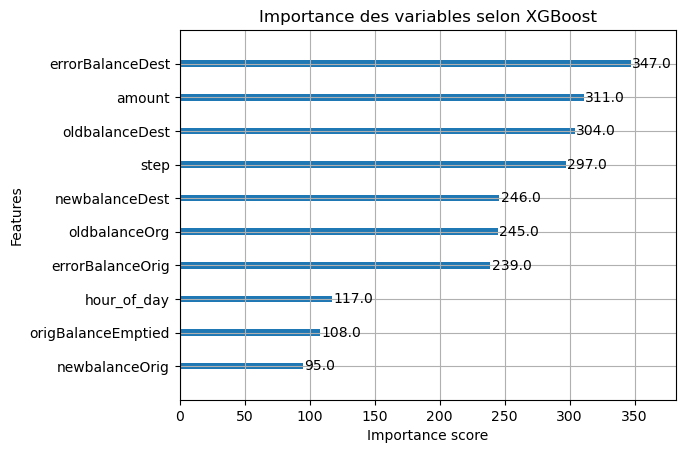

In [50]:
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(model_xgb, max_num_features=10)
plt.title('Importance des variables selon XGBoost')
plt.show()

## Importance des variables selon XGBoost

Contrairement a Random Forest, ou origBalanceEmptied dominait tres nettement des
la premiere question du premier arbre, XGBoost repartit son apprentissage sur
plusieurs variables, avec errorBalanceDest, amount, oldbalanceDest et step en tete,
origBalanceEmptied arrivant seulement en avant derniere position. Cette difference
s'explique par le mecanisme sequentiel de XGBoost : les premiers arbres captent
rapidement le signal fort (origBalanceEmptied), puis les arbres suivants se
concentrent sur les erreurs residuelles, exploitant des signaux plus fins. Cela
suggere une comprehension potentiellement plus nuancee et distribuee du probleme
par rapport a Random Forest.

**Choix du modèle final**

XGBoost a été retenu comme modèle final, plutôt que Random Forest malgré ses scores bruts légèrement supérieurs. Ce choix repose sur plusieurs arguments complémentaires. XGBoost obtient des performances globales excellentes et comparables, avec un ROC-AUC légèrement supérieur. L'analyse de l'importance des variables révèle un apprentissage plus distribué sur plusieurs signaux, contrairement à Random Forest qui dépend fortement d'une seule variable. Cette diversité se traduit par une meilleure robustesse, confirmée par le test de diagnostic où XGBoost conserve un meilleur Recall en l'absence des variables de solde les plus dominantes. Enfin, XGBoost est un standard largement adopté dans l'industrie pour la détection de fraude, offrant de meilleures perspectives d'évolution future du projet.

In [19]:
import joblib

joblib.dump(model_xgb, '../models/model_v1.pkl')
print("Modele sauvegarde dans ml/models/model_v1.pkl")

Modele sauvegarde dans ml/models/model_v1.pkl


In [20]:
import os
print(os.path.exists('../models/model_v1.pkl'))

True
